In [ ]:

# SECTION 0: IMPORTS & CONFIGURATION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

from pathlib import Path
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu

warnings.filterwarnings("ignore")

# ── Global Plot Style ──────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
})

# Color palette — binary focus first
PALETTE_BINARY = {0: "#2ecc71", 1: "#e74c3c"}
LABEL_MAP      = {0: "Low Risk", 1: "High Risk"}
COLORS         = ["#2ecc71", "#e74c3c"]

# Paths
PROJECT_ROOT = (
    Path.cwd().resolve().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd().resolve()
)
DATASET_PATH = PROJECT_ROOT / "data" / "raw" / "synthetic_gambling_data.csv"
FIGURES_DIR  = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Imports complete")
print(f"Figures → {FIGURES_DIR}")

Imports complete
Figures → /Users/tsing/Library/Mobile Documents/com~apple~CloudDocs/DataSci/Gambling-ML-/figures


In [27]:
# SECTION 1: LOAD RAW DATA
df_raw = pd.read_csv(DATASET_PATH)
df_raw.info()
df_raw.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 56 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   player_id                            10000 non-null  int64  
 1   prediction_year                      10000 non-null  int64  
 2   signup_date                          9537 non-null   object 
 3   account_tenure_days                  9463 non-null   float64
 4   age                                  9492 non-null   float64
 5   primary_product_type                 9514 non-null   object 
 6   synthetic_income_monthly             9512 non-null   float64
 7   debt_to_income_ratio                 9514 non-null   float64
 8   synthetic_credit_score               9517 non-null   float64
 9   credit_score_velocity_7d             9534 non-null   float64
 10  liquid_savings_balance               9484 non-null   float64
 11  liquid_savings_drawdown_rate 

,player_id,prediction_year,account_tenure_days,age,synthetic_income_monthly,debt_to_income_ratio,synthetic_credit_score,credit_score_velocity_7d,liquid_savings_balance,liquid_savings_drawdown_rate,...,push_notification_density,gambling_ad_ctr,vip_status,limit_setting_flag,deposit_limit_breach_attempts,time_out_requests_count,responsible_gambling_message_count,regulatory_friction_score,friction_bypass_attempt_flag,future_high_risk_flag
count,10000.00000,10000.0,9463.000000,9492.000000,9512.000000,9514.000000,9517.000000,9534.000000,9484.000000,9500.000000,...,9477.000000,9510.000000,9506.000000,9516.000000,9511.000000,9521.000000,9508.000000,9462.000000,9518.000000,10000.000000
mean,104999.50000,2026.0,1447.410018,43.316161,5090.074656,0.751139,576.963329,-10.422803,24930.888386,0.251881,...,24.504907,0.498269,0.097938,0.503993,1.995163,1.017645,9.439735,0.496302,0.495692,0.150000
std,2886.89568,0.0,429.916357,15.056639,1953.520396,0.431671,159.144159,11.564915,14370.975822,0.144243,...,14.480497,0.287570,0.297247,0.500010,1.409065,1.020125,5.740107,0.287676,0.500008,0.357089
min,100000.00000,2026.0,693.000000,18.000000,1000.000000,0.000071,300.000000,-30.000000,2.866653,0.000007,...,0.000000,0.000011,0.000000,0.000000,0.000000,0.000000,0.000000,0.000082,0.000000,0.000000
25%,102499.75000,2026.0,1075.000000,30.000000,3728.415059,0.374572,441.000000,-20.000000,12493.171302,0.129233,...,12.000000,0.250797,0.000000,0.000000,1.000000,0.000000,4.000000,0.244858,0.000000,0.000000
50%,104999.50000,2026.0,1451.000000,43.000000,5062.588178,0.754841,578.000000,-10.000000,24905.701286,0.252186,...,24.000000,0.492723,0.000000,1.000000,2.000000,1.000000,9.000000,0.494210,0.000000,0.000000
75%,107499.25000,2026.0,1820.000000,56.000000,6413.267592,1.119143,716.000000,0.000000,37262.589776,0.378349,...,37.000000,0.752194,0.000000,1.000000,3.000000,2.000000,14.000000,0.741261,1.000000,0.000000
max,109999.00000,2026.0,2192.000000,77.000000,12112.725571,1.499936,849.000000,9.000000,49999.686665,0.499830,...,49.000000,0.999885,1.000000,1.000000,9.000000,7.000000,19.000000,0.999970,1.000000,1.000000


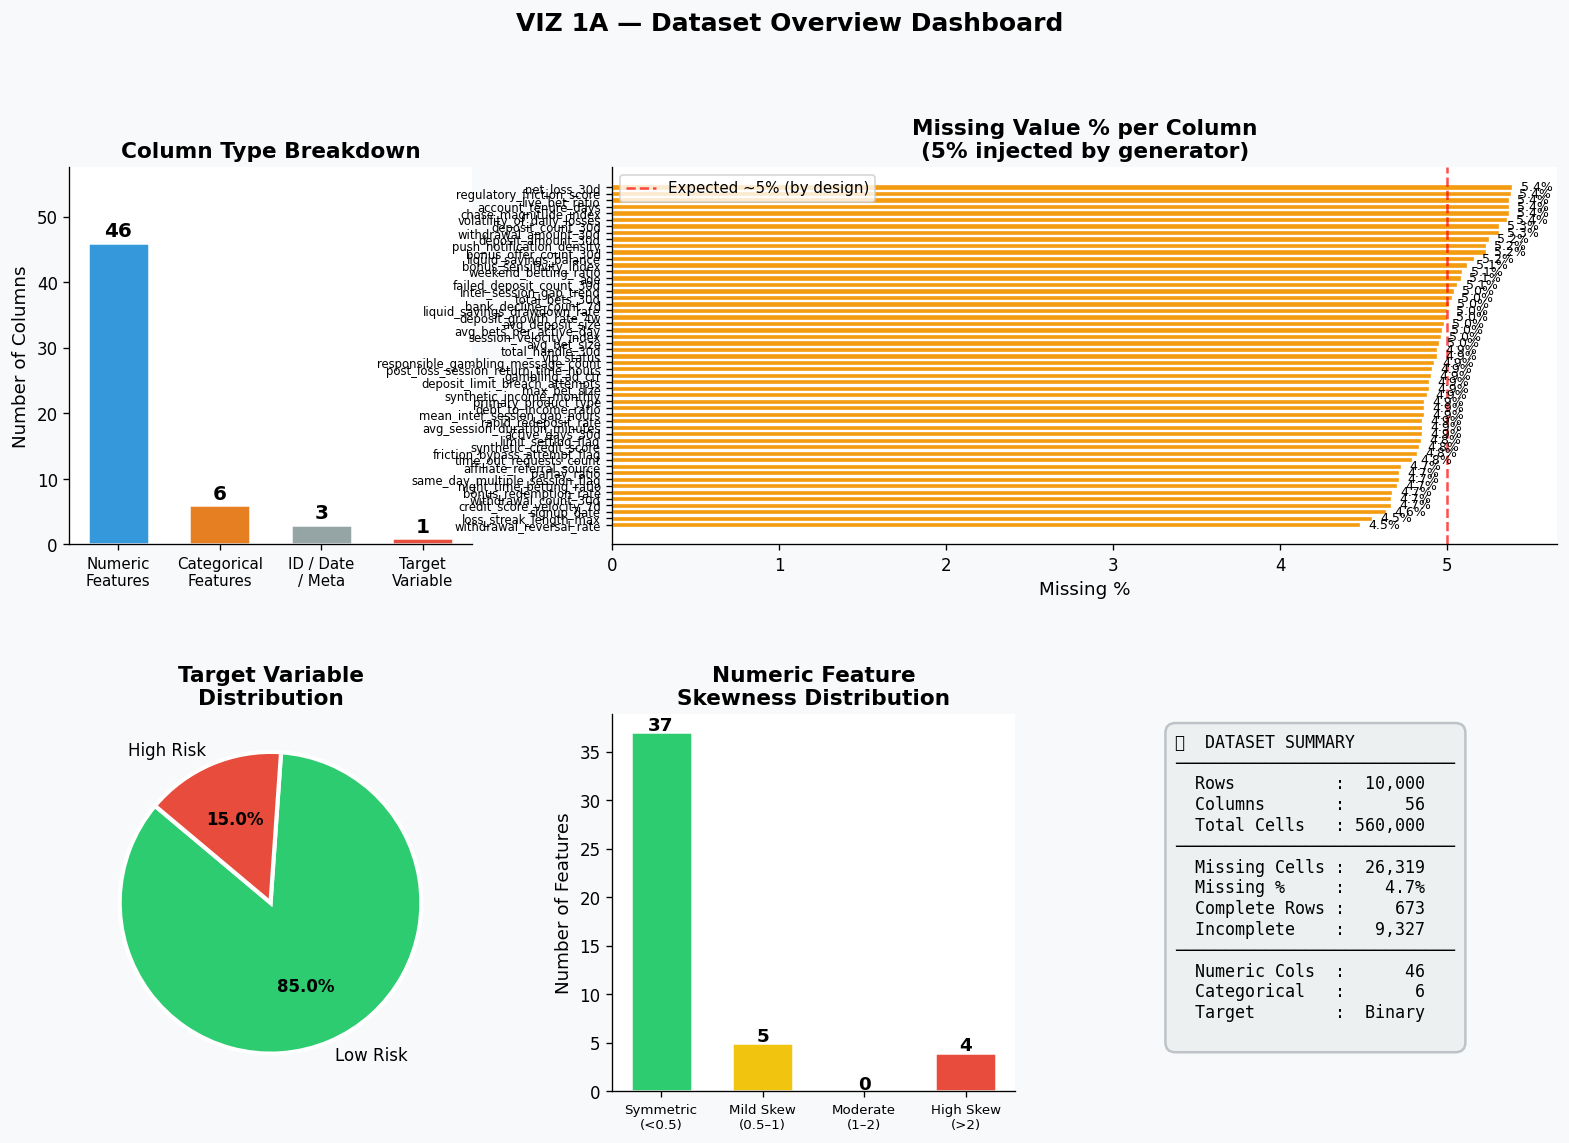

✅ VIZ 1A saved


In [ ]:

# VIZ 1A: Dataset Overview Dashboard

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("#f8f9fa")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Column type breakdown ────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

CAT_COLS = [
    "primary_product_type", "affiliate_referral_source",
    "vip_status", "limit_setting_flag",
    "same_day_multiple_session_flag", "friction_bypass_attempt_flag",
]
ID_DATE_META = ["player_id", "signup_date", "prediction_year"]
NUM_COLS = [
    c for c in df_raw.columns
    if c not in CAT_COLS + ID_DATE_META + [TARGET]
]

type_counts = {
    "Numeric\nFeatures"      : len(NUM_COLS),
    "Categorical\nFeatures"  : len(CAT_COLS),
    "ID / Date\n/ Meta"      : len(ID_DATE_META),
    "Target\nVariable"       : 1,
}
bar_colors = ["#3498db", "#e67e22", "#95a5a6", "#e74c3c"]
bars = ax1.bar(
    type_counts.keys(), type_counts.values(),
    color=bar_colors, edgecolor="white", linewidth=1.5, width=0.6
)
for bar, val in zip(bars, type_counts.values()):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(val), ha="center", va="bottom",
        fontsize=12, fontweight="bold"
    )
ax1.set_title("Column Type Breakdown")
ax1.set_ylabel("Number of Columns")
ax1.set_ylim(0, max(type_counts.values()) * 1.25)
ax1.tick_params(axis="x", labelsize=9)

# ── Panel 2: Missing values per column ────────────────────
ax2 = fig.add_subplot(gs[0, 1:])

missing = df_raw.isna().sum()
missing = missing[missing > 0].sort_values(ascending=True)
missing_pct = (missing / len(df_raw) * 100)

colors_miss = [
    "#e74c3c" if p > 7 else "#f39c12" if p > 4 else "#2ecc71"
    for p in missing_pct
]
bars2 = ax2.barh(
    missing.index, missing_pct.values,
    color=colors_miss, edgecolor="white", linewidth=0.8
)
for bar, val in zip(bars2, missing_pct.values):
    ax2.text(
        val + 0.05, bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%", va="center", fontsize=7.5
    )
ax2.axvline(5, color="red", linestyle="--", linewidth=1.5,
            alpha=0.7, label="Expected ~5% (by design)")
ax2.set_title("Missing Value % per Column\n(5% injected by generator)")
ax2.set_xlabel("Missing %")
ax2.legend(fontsize=9)
ax2.tick_params(axis="y", labelsize=7)

# ── Panel 3: Target distribution ──────────────────────────
ax3 = fig.add_subplot(gs[1, 0])

target_counts = df_raw[TARGET].value_counts().sort_index()
wedges, texts, autotexts = ax3.pie(
    target_counts.values,
    labels=[LABEL_MAP[i] for i in target_counts.index],
    colors=COLORS,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2.5},
    textprops={"fontsize": 10},
)
for at in autotexts:
    at.set_fontweight("bold")
ax3.set_title("Target Variable\nDistribution")

# ── Panel 4: Numeric column stats summary ─────────────────
ax4 = fig.add_subplot(gs[1, 1])

skewness = df_raw[NUM_COLS].skew().abs()
skew_bins = pd.cut(
    skewness,
    bins=[-np.inf, 0.5, 1.0, 2.0, np.inf],
    labels=["Symmetric\n(<0.5)", "Mild Skew\n(0.5–1)", 
            "Moderate\n(1–2)", "High Skew\n(>2)"]
)
skew_counts = skew_bins.value_counts().sort_index()
ax4.bar(
    skew_counts.index, skew_counts.values,
    color=["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"],
    edgecolor="white", linewidth=1.5, width=0.6
)
for i, val in enumerate(skew_counts.values):
    ax4.text(i, val + 0.2, str(val), ha="center",
             fontsize=11, fontweight="bold")
ax4.set_title("Numeric Feature\nSkewness Distribution")
ax4.set_ylabel("Number of Features")
ax4.tick_params(axis="x", labelsize=8)

# ── Panel 5: Dataset size summary text ────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis("off")

total_cells  = df_raw.shape[0] * df_raw.shape[1]
missing_cells= df_raw.isna().sum().sum()
complete_rows= df_raw.dropna().shape[0]

summary_text = (
    f"📊  DATASET SUMMARY\n"
    f"{'─'*28}\n"
    f"  Rows          : {df_raw.shape[0]:>7,}\n"
    f"  Columns       : {df_raw.shape[1]:>7,}\n"
    f"  Total Cells   : {total_cells:>7,}\n"
    f"{'─'*28}\n"
    f"  Missing Cells : {missing_cells:>7,}\n"
    f"  Missing %     : {missing_cells/total_cells*100:>6.1f}%\n"
    f"  Complete Rows : {complete_rows:>7,}\n"
    f"  Incomplete    : {df_raw.shape[0]-complete_rows:>7,}\n"
    f"{'─'*28}\n"
    f"  Numeric Cols  : {len(NUM_COLS):>7,}\n"
    f"  Categorical   : {len(CAT_COLS):>7,}\n"
    f"  Target        : {'Binary':>7}\n"
)
ax5.text(
    0.05, 0.95, summary_text,
    transform=ax5.transAxes,
    fontsize=10, verticalalignment="top",
    fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#ecf0f1",
              edgecolor="#bdc3c7", linewidth=1.5)
)

plt.suptitle(
    "VIZ 1A — Dataset Overview Dashboard",
    fontsize=15, fontweight="bold", y=1.01
)
plt.savefig(FIGURES_DIR / "VIZ_1A_dataset_overview.png", bbox_inches="tight")
plt.show()
print("✅ VIZ 1A saved")

In [ ]:
# SECTION 2: DATA CLEANING

#1. copy data 
df = df_raw.copy()

# ── 2.1 Parse dates ────────────────────────────────────────
df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce")


df.head()



,player_id,prediction_year,signup_date,account_tenure_days,age,primary_product_type,synthetic_income_monthly,debt_to_income_ratio,synthetic_credit_score,credit_score_velocity_7d,...,gambling_ad_ctr,affiliate_referral_source,vip_status,limit_setting_flag,deposit_limit_breach_attempts,time_out_requests_count,responsible_gambling_message_count,regulatory_friction_score,friction_bypass_attempt_flag,future_high_risk_flag
0,100000,2026,2020-05-13,2059.0,35.0,sportsbook,7856.862293,0.478492,504.0,-18.0,...,0.363911,vip,1.0,0.0,1.0,0.0,11.0,0.772816,0.0,0
1,100001,2026,2023-03-06,1032.0,29.0,casino,8528.482154,0.179986,332.0,9.0,...,0.657499,influencer,0.0,1.0,2.0,2.0,11.0,0.441618,1.0,1
2,100002,2026,2022-09-08,NaN,45.0,sportsbook,5660.952159,0.018944,709.0,-7.0,...,0.768930,organic,0.0,0.0,1.0,0.0,9.0,0.188382,0.0,0
3,100003,2026,2021-10-20,1534.0,52.0,casino,2544.901965,0.905510,467.0,-3.0,...,0.421780,influencer,0.0,0.0,1.0,3.0,12.0,0.973230,1.0,0
4,100004,2026,2021-10-11,1543.0,31.0,casino,8545.045862,NaN,550.0,4.0,...,0.270741,vip,0.0,0.0,2.0,1.0,16.0,0.957904,NaN,0


In [13]:

# ── 2.2 Column type registry ───────────────────────────────
ID_COLS    = ["player_id"]
DATE_COLS  = ["signup_date"]
TARGET     = "future_high_risk_flag"
META_COLS  = ["prediction_year"]

CAT_COLS = [
    "primary_product_type",
    "affiliate_referral_source",
    "vip_status",
    "limit_setting_flag",
    "same_day_multiple_session_flag",
    "friction_bypass_attempt_flag",
]

NUM_COLS = [
    c for c in df.columns
    if c not in ID_COLS + DATE_COLS + [TARGET] + CAT_COLS + META_COLS
]

print(f"Numeric   : {len(NUM_COLS)}")
print(f"Categorical: {len(CAT_COLS)}")

Numeric   : 46
Categorical: 6


In [14]:
# ── 2.3 Missing value report ───────────────────────────────
missing_report = (
    df[NUM_COLS + CAT_COLS]
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)
missing_report["missing_pct"] = (
    missing_report["missing_count"] / len(df) * 100
).round(2)
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values(
    "missing_pct", ascending=False
)

print(f"\nColumns with missing values: {len(missing_report)}")
print(missing_report.to_string(index=False))



Columns with missing values: 52
                             column  missing_count  missing_pct
                       net_loss_30d            539         5.39
          regulatory_friction_score            538         5.38
                account_tenure_days            537         5.37
              chase_magnitude_index            537         5.37
                     live_bet_ratio            537         5.37
         volatility_of_daily_losses            536         5.36
              withdrawal_amount_30d            531         5.31
                  deposit_count_30d            531         5.31
                 deposit_amount_30d            525         5.25
          push_notification_density            523         5.23
              bonus_offer_count_30d            523         5.23
             liquid_savings_balance            516         5.16
            bonus_sensitivity_index            512         5.12
              weekend_betting_ratio            509         5.09
       

In [ ]:
#  2.4 Imputation 
#There are about 5% missing in every column so dropiing those cloumns will be a bad idea. 
# Numeric → median (robust to skew & outliers)
for col in NUM_COLS:
    if df[col].isna().any():
        df[col].fillna(df[col].median(), inplace=True)

# Categorical → mode
for col in CAT_COLS:
    if df[col].isna().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f"\n Missing after imputation: {df[NUM_COLS + CAT_COLS].isna().sum().sum()}")


 Missing after imputation: 0


In [ ]:
# 2.5 Outlier capping (IQR × 3 soft winsorization) 


def cap_outliers_iqr(series: pd.Series, factor: float = 3.0) -> pd.Series:
    """Soft winsorization — only caps extreme outliers."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(lower=Q1 - factor * IQR, upper=Q3 + factor * IQR)

capped_cols = []
for col in NUM_COLS:
    original = df[col].copy()
    df[col]  = cap_outliers_iqr(df[col])
    n_capped = (df[col] != original).sum()
    if n_capped > 0:
        capped_cols.append((col, n_capped))

print(f"\nOutlier capping applied to {len(capped_cols)} columns:")
for col, n in sorted(capped_cols, key=lambda x: -x[1])[:10]:
    print(f"  {col:<45} {n:>5} values capped")



Outlier capping applied to 46 columns:
  net_loss_30d                                    539 values capped
  regulatory_friction_score                       538 values capped
  account_tenure_days                             537 values capped
  live_bet_ratio                                  537 values capped
  chase_magnitude_index                           537 values capped
  volatility_of_daily_losses                      536 values capped
  deposit_count_30d                               531 values capped
  withdrawal_amount_30d                           531 values capped
  deposit_amount_30d                              525 values capped
  bonus_offer_count_30d                           523 values capped


In [ ]:
# 2.6 Age sanity check 
print(f"\nAge range before clip: {df['age'].min()} – {df['age'].max()}")
df["age"] = df["age"].clip(18, 90)
print(f"Age range after  clip: {df['age'].min()} – {df['age'].max()}")



Age range before clip: 18.0 – 77.0
Age range after  clip: 18.0 – 77.0


In [18]:
# ── 2.7 Duplicate player check ────────────────────────────
# NOTE: One person = one account rule
# Check if same player_id appears more than once
dup_players = df.duplicated(subset=["player_id"], keep=False).sum()
print(f"\nDuplicate player_id rows: {dup_players}")
if dup_players > 0:
    print(df[df.duplicated(subset=["player_id"], keep=False)]
          [["player_id", "prediction_year", "signup_date"]].head(10))
    # Keep the most recent record per player
    df.sort_values("signup_date", ascending=False, inplace=True)
    df.drop_duplicates(subset=["player_id"], keep="first", inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"  → Kept latest record per player. New shape: {df.shape}")



Duplicate player_id rows: 0


In [ ]:
# ── 2.8 Multi-account detection (day/night proxy) ─────────
# Flag players who have both high night_time_betting_ratio AND
# same_day_multiple_session_flag — proxy for possible multi-account behavior

#fe part 1 - create a new flag colum for muti

df["multi_account_risk_flag"] = (
    (df["night_time_betting_ratio"] > 0.7) &
    (df["same_day_multiple_session_flag"] == 1)
).astype(int)

print(f"\nMulti-account risk flags: {df['multi_account_risk_flag'].sum():,} "
      f"({df['multi_account_risk_flag'].mean()*100:.1f}%)")

print(f"\n Final cleaned shape: {df.shape}")


Multi-account risk flags: 1,366 (13.7%)

 Final cleaned shape: (10000, 57)


In [32]:
df.describe()

,player_id,prediction_year,signup_date,account_tenure_days,age,synthetic_income_monthly,debt_to_income_ratio,synthetic_credit_score,credit_score_velocity_7d,liquid_savings_balance,...,push_notification_density,gambling_ad_ctr,vip_status,limit_setting_flag,deposit_limit_breach_attempts,time_out_requests_count,responsible_gambling_message_count,regulatory_friction_score,friction_bypass_attempt_flag,future_high_risk_flag
count,10000.00000,10000.0,9537,9463.000000,9492.000000,9512.000000,9514.000000,9517.000000,9534.000000,9484.000000,...,9477.000000,9510.000000,9506.000000,9516.000000,9511.000000,9521.000000,9508.000000,9462.000000,9518.000000,10000.000000
mean,104999.50000,2026.0,2022-01-14 02:22:14.004403712,1447.410018,43.316161,5090.074656,0.751139,576.963329,-10.422803,24930.888386,...,24.504907,0.498269,0.097938,0.503993,1.995163,1.017645,9.439735,0.496302,0.495692,0.150000
min,100000.00000,2026.0,2020-01-01 00:00:00,693.000000,18.000000,1000.000000,0.000071,300.000000,-30.000000,2.866653,...,0.000000,0.000011,0.000000,0.000000,0.000000,0.000000,0.000000,0.000082,0.000000,0.000000
25%,102499.75000,2026.0,2021-01-06 00:00:00,1075.000000,30.000000,3728.415059,0.374572,441.000000,-20.000000,12493.171302,...,12.000000,0.250797,0.000000,0.000000,1.000000,0.000000,4.000000,0.244858,0.000000,0.000000
50%,104999.50000,2026.0,2022-01-11 00:00:00,1451.000000,43.000000,5062.588178,0.754841,578.000000,-10.000000,24905.701286,...,24.000000,0.492723,0.000000,1.000000,2.000000,1.000000,9.000000,0.494210,0.000000,0.000000
75%,107499.25000,2026.0,2023-01-23 00:00:00,1820.000000,56.000000,6413.267592,1.119143,716.000000,0.000000,37262.589776,...,37.000000,0.752194,0.000000,1.000000,3.000000,2.000000,14.000000,0.741261,1.000000,0.000000
max,109999.00000,2026.0,2024-02-08 00:00:00,2192.000000,77.000000,12112.725571,1.499936,849.000000,9.000000,49999.686665,...,49.000000,0.999885,1.000000,1.000000,9.000000,7.000000,19.000000,0.999970,1.000000,1.000000
std,2886.89568,0.0,NaN,429.916357,15.056639,1953.520396,0.431671,159.144159,11.564915,14370.975822,...,14.480497,0.287570,0.297247,0.500010,1.409065,1.020125,5.740107,0.287676,0.500008,0.357089
